## 0. Tiền xử lý dữ liệu

Import các thư viện cần thiết để xử lý dữ liệu nhiệt độ và thiết lập cấu hình trực quan hóa.


In [1]:
import os
import gc
import xarray as xr
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

Xây dựng hàm con để xử lý dữ liệu thô từ ERA5. Trong bước này, chúng ta thực hiện các thao tác vật lý quan trọng:
- **Chuẩn hóa tọa độ**: Đồng bộ hóa biến thời gian và xử lý chiều `expver`.
- **Chuyển đổi đơn vị**: Đưa nhiệt độ từ Kelvin về Celsius (°C).
- **Trích xuất chỉ số**: 
    - `t2m`: Nhiệt độ không khí ở độ cao 2m.
    - `tskin`: Nhiệt độ bề mặt (Skin temperature).
    - `tmax/tmin`: Các giá trị cực trị trong ngày để phục vụ phân tích nắng nóng và biên độ nhiệt.
- **Tính toán Climatology**: Xác định mức trung bình lịch sử để làm cơ sở tính toán dị thường (Anomalies).

In [2]:
def load_and_aggregate_temp(t2m_file, skin_file, tmax_file):
    def preprocess(ds):
        if 'valid_time' in ds.coords: ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims: ds = ds.mean(dim='expver')
        return ds.sortby('time')

    ds_t2m = preprocess(xr.open_dataset(os.path.join(folder_path, t2m_file)))
    var_t2m = list(ds_t2m.data_vars)[0]
    t2m = ds_t2m[var_t2m] - 273.15
    d_mean_t2m = t2m.resample(time='1D').mean().mean(dim=['latitude', 'longitude']).compute()
    d_min_t2m = t2m.resample(time='1D').min().mean(dim=['latitude', 'longitude']).compute()
    ds_t2m.close()

    ds_skin = preprocess(xr.open_dataset(os.path.join(folder_path, skin_file)))
    var_skin = list(ds_skin.data_vars)[0]
    tskin = (ds_skin[var_skin] - 273.15).mean(dim=['latitude', 'longitude']).resample(time='1D').mean().compute()
    ds_skin.close()

    ds_tmax = preprocess(xr.open_dataset(os.path.join(folder_path, tmax_file)))
    var_tmax = list(ds_tmax.data_vars)[0]
    d_max_t2m = (ds_tmax[var_tmax] - 273.15).resample(time='1D').max().mean(dim=['latitude', 'longitude']).compute()
    ds_tmax.close()

    df_daily = pd.DataFrame({
        't2m': d_mean_t2m.values,
        'tskin': tskin.values,
        'tmax': d_max_t2m.values,
        'tmin': d_min_t2m.values
    }, index=d_mean_t2m.time.values)
    
    df_monthly = df_daily[['t2m', 'tskin']].resample('ME').mean()
    climatology = df_monthly.groupby(df_monthly.index.month).mean()
    
    df_monthly['month'] = df_monthly.index.month
    df_monthly['t2m_anom'] = df_monthly.apply(lambda x: x['t2m'] - climatology.loc[x['month'], 't2m'], axis=1)
    
    gc.collect()
    return df_daily, df_monthly, climatology

Thực thi hàm xử lý dữ liệu và kiểm tra cấu trúc của DataFrame hàng ngày sau khi tích hợp.

In [3]:
df_daily, df_monthly, climatology = load_and_aggregate_temp(
    '2m_temperature_merged.nc', 
    'skin_temperature_merged.nc', 
    'maximum_2m_temperature_since_previous_post_processing_merged.nc'
)
df_daily.head()

,t2m,tskin,tmax,tmin
1980-01-01,23.688829,23.484545,27.713270,19.988638
1980-01-02,23.533554,23.595791,27.831284,19.702925
1980-01-03,23.554111,23.542620,27.703239,19.808546
1980-01-04,22.988264,23.372946,26.877628,19.011393
1980-01-05,21.940742,22.414463,24.946575,18.955507


## 1. Xu hướng thay đổi nhiệt độ hàng năm

Biểu đồ so sánh xu hướng biến thiên dài hạn của nhiệt độ không khí và nhiệt độ bề mặt đất qua 45 năm. 

Thông qua đường hồi quy tuyến tính, ta có thể xác định tốc độ nóng lên của khu vực. Thông thường, nhiệt độ bề mặt đất (`tskin`) phản ứng nhạy hơn với bức xạ mặt trời trực tiếp và có biên độ biến động mạnh hơn so với nền nhiệt không khí.

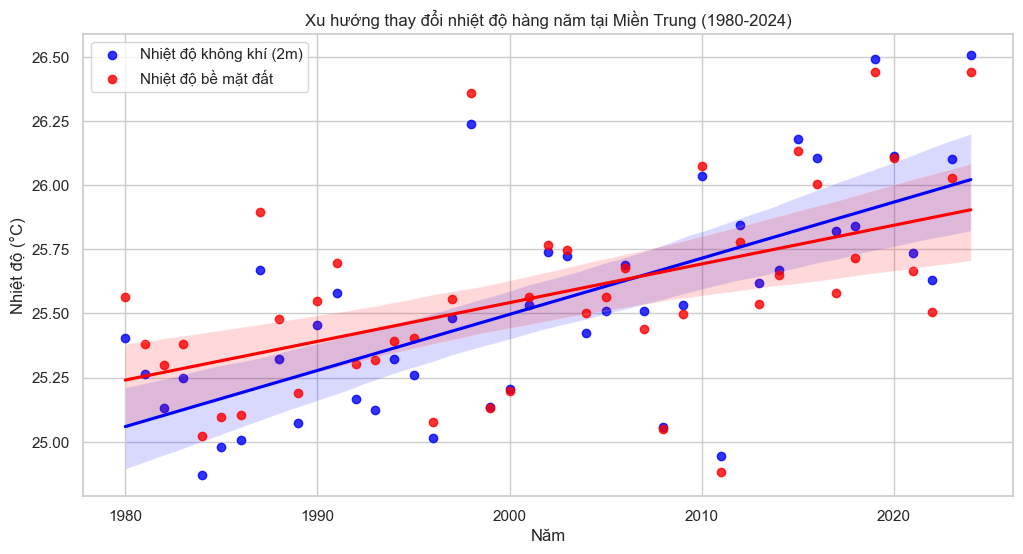

In [4]:
df_yearly = df_daily[['t2m', 'tskin']].resample('YS').mean()
df_yearly['Year'] = df_yearly.index.year

plt.figure(figsize=(12, 6))
sns.regplot(data=df_yearly, x='Year', y='t2m', color='blue', label='Nhiệt độ không khí (2m)')
sns.regplot(data=df_yearly, x='Year', y='tskin', color='red', label='Nhiệt độ bề mặt đất')

plt.title("Xu hướng thay đổi nhiệt độ hàng năm tại Miền Trung (1980-2024)")
plt.ylabel("Nhiệt độ (°C)")
plt.xlabel("Năm")
plt.legend()
plt.show()

## 2. Chu kỳ mùa trung bình (Climatology)

Phân tích quy luật mùa dựa trên giá trị trung bình của từng tháng trong suốt 45 năm. 

Khoảng tô màu xám giữa hai đường biểu diễn sự chênh lệch nhiệt độ giữa đất và không khí. Đây là chỉ số quan trọng để hiểu về quá trình trao đổi nhiệt cảm (Sensible heat flux) từ mặt đất lên khí quyển.

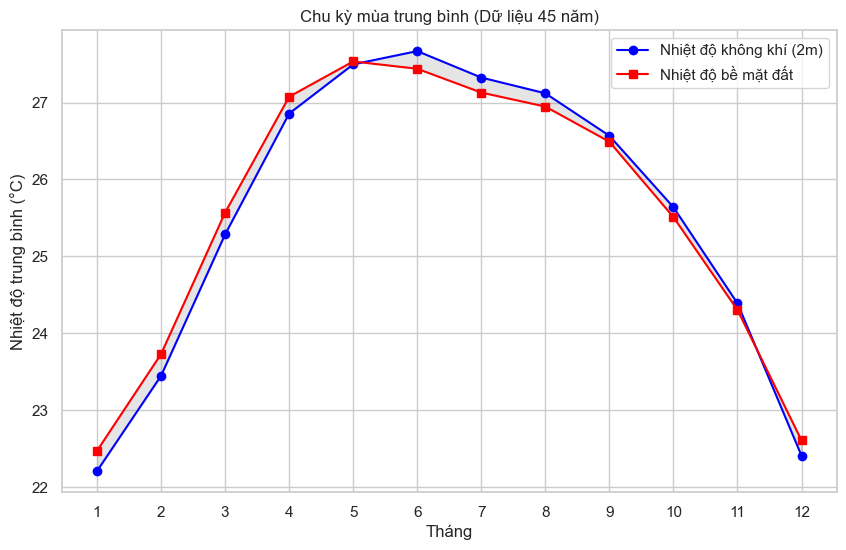

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(climatology.index, climatology['t2m'], marker='o', color='blue', label='Nhiệt độ không khí (2m)')
plt.plot(climatology.index, climatology['tskin'], marker='s', color='red', label='Nhiệt độ bề mặt đất')
plt.fill_between(climatology.index, climatology['t2m'], climatology['tskin'], color='gray', alpha=0.2)
plt.title("Chu kỳ mùa trung bình (Dữ liệu 45 năm)")
plt.xticks(range(1, 13))
plt.xlabel("Tháng")
plt.ylabel("Nhiệt độ trung bình (°C)")
plt.legend()
plt.show()

## 3. Ma trận dị thường nhiệt độ hàng tháng

Heatmap này thể hiện mức độ lệch nhiệt độ (`t2m_anom`) so với trung bình lịch sử của cùng một tháng. 
- **Sắc đỏ đậm**: Đại diện cho các tháng nóng bất thường (có thể liên quan đến hiện tượng El Niño hoặc các đợt sóng nhiệt).
- **Sắc xanh**: Đại diện cho các tháng mát mẻ hơn bình thường (dấu hiệu của La Niña hoặc các giai đoạn mưa lớn kéo dài).

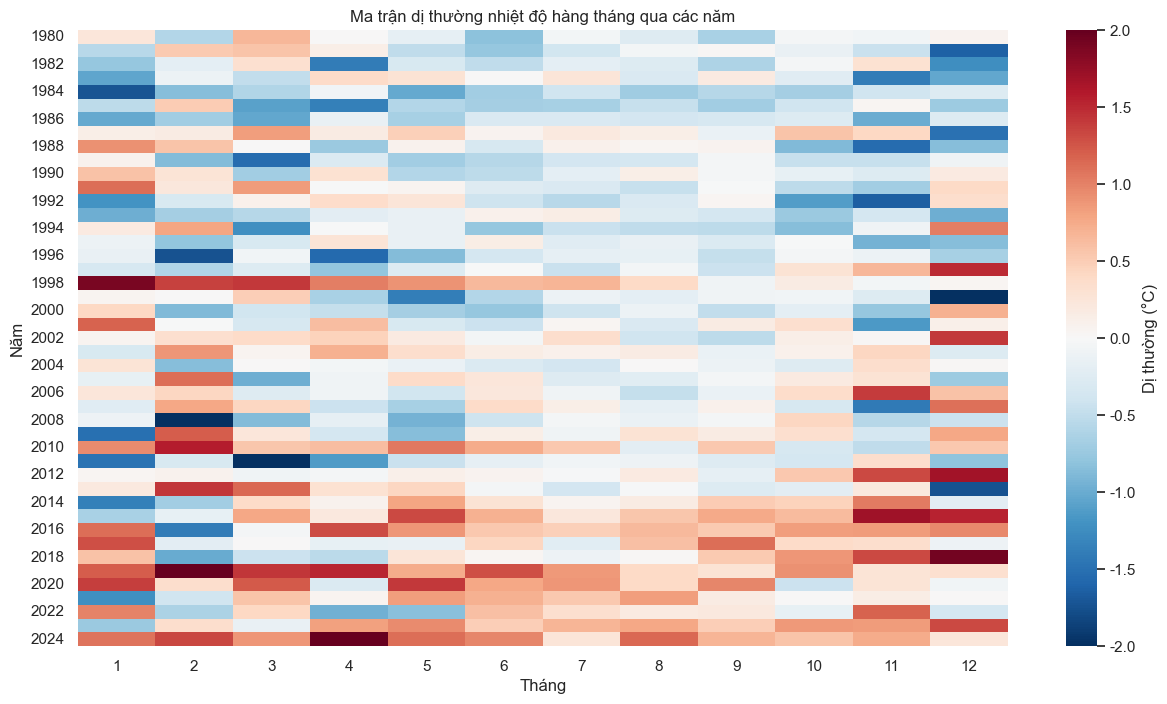

In [6]:
pivot_anom = df_monthly.copy()
pivot_anom['Year'] = pivot_anom.index.year
pivot_anom['Month'] = pivot_anom.index.month
pivot_table = pivot_anom.pivot(index='Year', columns='Month', values='t2m_anom')

plt.figure(figsize=(15, 8))
sns.heatmap(pivot_table, cmap="RdBu_r", center=0, vmin=-2, vmax=2, cbar_kws={'label': 'Dị thường (°C)'})
plt.title("Ma trận dị thường nhiệt độ hàng tháng qua các năm")
plt.xlabel("Tháng")
plt.ylabel("Năm")
plt.show()

## 4. Tần suất các ngày nắng nóng cực đoan

Đếm số ngày trong năm có nhiệt độ cực đại ($T_{max}$) vượt ngưỡng 32°C. 

Biểu đồ cột kết hợp với đường trung bình trượt 5 năm giúp loại bỏ các biến động nhiễu ngắn hạn, làm lộ rõ xu hướng gia tăng tần suất các hiện tượng nhiệt độ cực đoan theo thời gian.

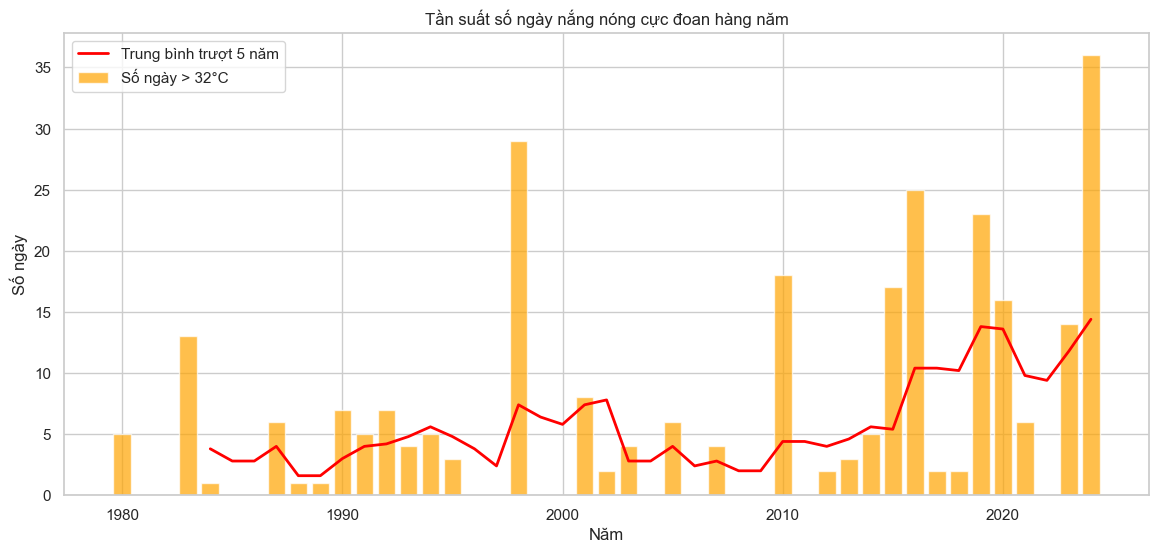

In [7]:
hot_days_count = (df_daily['tmax'] > 32).resample('YS').sum()

plt.figure(figsize=(14, 6))
plt.bar(hot_days_count.index.year, hot_days_count.values, color='orange', alpha=0.7, label='Số ngày > 32°C')
plt.plot(hot_days_count.index.year, hot_days_count.rolling(5).mean(), color='red', linewidth=2, label='Trung bình trượt 5 năm')

plt.title("Tần suất số ngày nắng nóng cực đoan hàng năm")
plt.ylabel("Số ngày")
plt.xlabel("Năm")
plt.legend()
plt.show()

## 5. Biến động biên độ nhiệt ngày (DTR)

Biên độ nhiệt ngày ($DTR = T_{max} - T_{min}$) là một chỉ số nhạy cảm với biến đổi khí hậu. 

Nếu $DTR$ có xu hướng giảm, điều đó thường có nghĩa là nhiệt độ ban đêm ($T_{min}$) đang tăng nhanh hơn nhiệt độ ban ngày ($T_{max}$) – một đặc điểm điển hình của sự gia tăng nồng độ khí nhà kính và độ che phủ của mây.

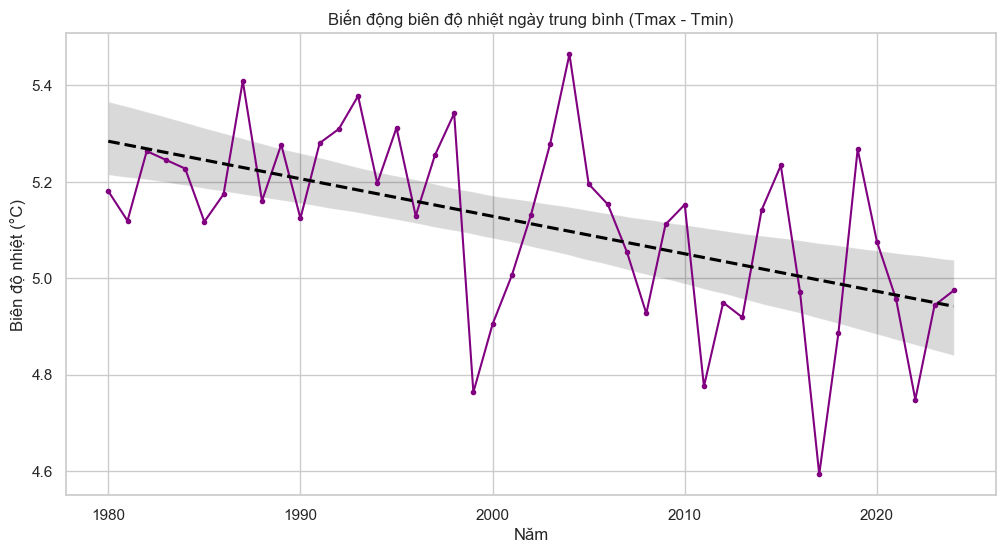

In [8]:
df_daily['DTR'] = df_daily['tmax'] - df_daily['tmin']
dtr_yearly = df_daily['DTR'].resample('YS').mean()

plt.figure(figsize=(12, 6))
plt.plot(dtr_yearly.index.year, dtr_yearly.values, marker='.', color='purple')
sns.regplot(x=dtr_yearly.index.year, y=dtr_yearly.values, scatter=False, color='black', line_kws={'linestyle':'--'})

plt.title("Biến động biên độ nhiệt ngày trung bình (Tmax - Tmin)")
plt.ylabel("Biên độ nhiệt (°C)")
plt.xlabel("Năm")
plt.show()

## 6. Sự dịch chuyển phân phối nhiệt độ qua các thập kỷ

Sử dụng biểu đồ Boxplot để quan sát sự thay đổi trong cấu trúc phân phối nhiệt độ qua từng giai đoạn 10 năm. Sự dịch chuyển của các hộp (box) lên phía trên là minh chứng trực quan cho sự thay đổi nền nhiệt độ giữa các thế hệ dữ liệu.

C:\Users\Admin\AppData\Local\Temp\ipykernel_27624\2624157621.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_daily, x='Decade_Label', y='t2m', palette='coolwarm')


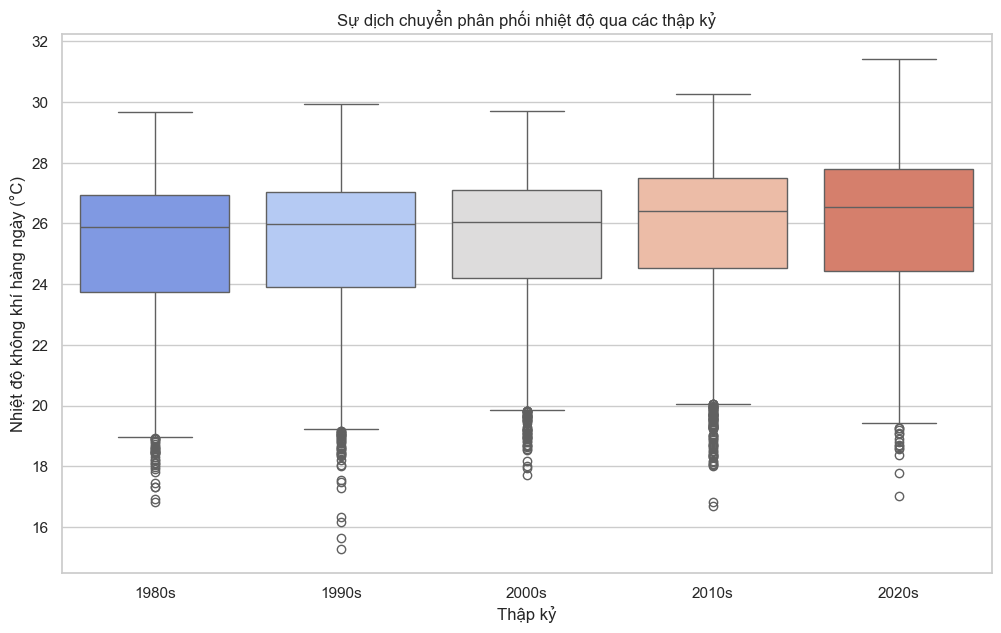

In [9]:
df_daily['Decade'] = (df_daily.index.year // 10) * 10
df_daily['Decade_Label'] = df_daily['Decade'].astype(str) + 's'

plt.figure(figsize=(12, 7))
sns.boxplot(data=df_daily, x='Decade_Label', y='t2m', palette='coolwarm')

plt.title("Sự dịch chuyển phân phối nhiệt độ qua các thập kỷ")
plt.xlabel("Thập kỷ")
plt.ylabel("Nhiệt độ không khí hàng ngày (°C)")
plt.show()

## 7. Tương quan vật lý giữa bề mặt đất và khí quyển

Biểu đồ Scatter plot thể hiện mối quan hệ cộng sinh giữa bề mặt đất và lớp không khí sát mặt đất. 
- **Màu sắc**: Phân hóa theo tháng (mùa) trong năm.
- **Đường $y=x$**: Đường tham chiếu giúp nhận diện thời điểm nào mặt đất đóng vai trò là nguồn sưởi (nằm trên đường) hoặc nguồn thu nhiệt từ khí quyển.

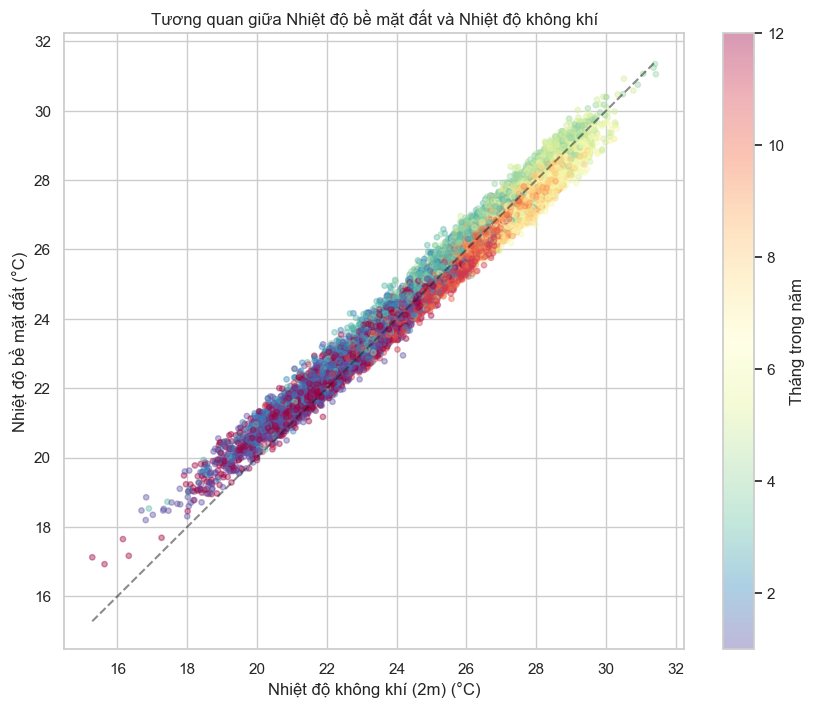

In [10]:
plt.figure(figsize=(10, 8))
df_daily['Tháng'] = df_daily.index.month

scatter = plt.scatter(df_daily['t2m'], df_daily['tskin'], 
                      c=df_daily['Tháng'], cmap='Spectral_r', alpha=0.4, s=15)

plt.colorbar(scatter, label='Tháng trong năm')
plt.plot([df_daily['t2m'].min(), df_daily['t2m'].max()], 
         [df_daily['t2m'].min(), df_daily['t2m'].max()], 'k--', alpha=0.5)

plt.title("Tương quan giữa Nhiệt độ bề mặt đất và Nhiệt độ không khí")
plt.xlabel("Nhiệt độ không khí (2m) (°C)")
plt.ylabel("Nhiệt độ bề mặt đất (°C)")
plt.show()

In [11]:
output_dir = r'D:\GitHub\climate-analysis-and-prediction\data\air_n_surface_temp'
os.makedirs(output_dir, exist_ok=True)

df_daily.to_parquet(f"{output_dir}/daily.parquet", compression='snappy')
df_monthly.to_parquet(f"{output_dir}/monthly.parquet", compression='snappy')
climatology.to_parquet(f"{output_dir}/climatology.parquet", compression='snappy')

print("✅ Saved parquet cache to air_n_surface_temp")

✅ Saved parquet cache to air_n_surface_temp
